In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
print(tf.__version__)

2.9.1


In [7]:
train_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/train',
    target_size=(224, 224),  # Resize images to a specific size
    batch_size=8,  # Set the batch size based on your hardware capabilities
    class_mode='categorical',  # Specify the type of classification task
    shuffle=True  # Shuffle the data for better training
)

test_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/test',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # Don't shuffle the test data
)

val_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/val',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=True  # Don't shuffle the test data
)

Found 8040 images belonging to 3 classes.
Found 252 images belonging to 3 classes.
Found 402 images belonging to 3 classes.


In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes (healthy, caterpillar, leafspot)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using the train_generator
model.fit(train_generator, epochs=24, validation_data=val_generator)

Epoch 1/24
1005/1005 [==============================] - 62s 61ms/step - loss: 0.5128 - accuracy: 0.8623 - val_loss: 1.0466 - val_accuracy: 0.7214
Epoch 2/24
1005/1005 [==============================] - 61s 61ms/step - loss: 0.0610 - accuracy: 0.9843 - val_loss: 1.6320 - val_accuracy: 0.6716
Epoch 3/24
1005/1005 [==============================] - 66s 66ms/step - loss: 0.0279 - accuracy: 0.9932 - val_loss: 1.9842 - val_accuracy: 0.6642
Epoch 4/24
1005/1005 [==============================] - 58s 58ms/step - loss: 0.0016 - accuracy: 1.0000 - val_loss: 2.2676 - val_accuracy: 0.6766
Epoch 5/24
1005/1005 [==============================] - 59s 58ms/step - loss: 3.4734e-04 - accuracy: 1.0000 - val_loss: 2.9008 - val_accuracy: 0.7438
Epoch 6/24
1005/1005 [==============================] - 60s 60ms/step - loss: 0.0927 - accuracy: 0.9740 - val_loss: 2.4504 - val_accuracy: 0.6368
Epoch 7/24
1005/1005 [==============================] - 59s 59ms/step - loss: 0.0133 - accuracy: 0.9974 - val_loss: 2.61

KeyboardInterrupt: 

In [4]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 394272)            0         
                                                                 
 dense (Dense)               (None, 3)                 1182819   
                                                                 
Total params: 1,183,715
Trainable params: 1,183,715
Non-trainable params: 0
_________________________________________________________________


32/32 [==============================] - 1s 25ms/step
Classification Report:
              precision    recall  f1-score   support

 caterpillar       0.92      0.67      0.77        99
     healthy       0.60      0.73      0.66        81
    leafspot       0.73      0.83      0.78        72

    accuracy                           0.73       252
   macro avg       0.75      0.74      0.74       252
weighted avg       0.76      0.73      0.74       252



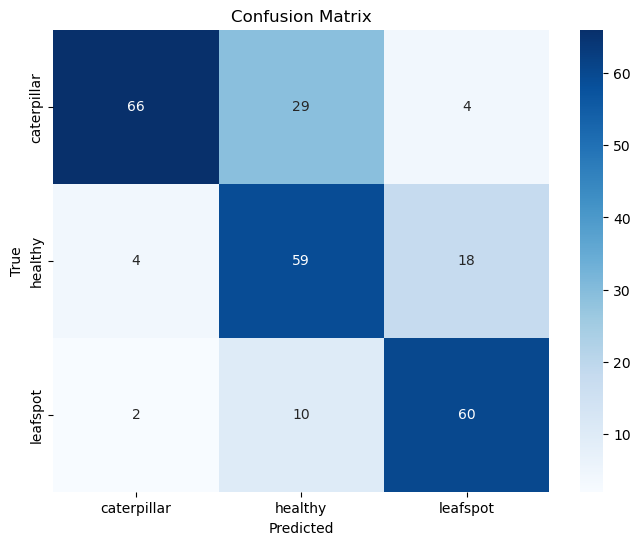

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate the model on the test data
test_results = model.evaluate(test_generator)

# Make predictions on the test data
y_pred = model.predict(test_generator)
# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test generator
y_true = test_generator.classes

# Generate the classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices)

print("Classification Report:")
print(class_report)

# Generate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()